# 01 — RCT foundations

**Stage 1.** Verifies that randomization holds (covariate balance), estimates
the ATE with design-based (Neyman) inference, documents what effect sizes are
detectable at a ~0.3% conversion base rate, and certifies the 1M-row
development subsample as representative of the full 13,979,592-row data.

Runs on **committed artifacts only** (Tier 1/2): the dev parquet and
`results/stage1/` outputs of `scripts/01_make_dev_subsample.py`. Every
headline number is asserted — the notebook fails loudly if any number drifts.
The Hillstrom section is skipped gracefully if the raw file is absent.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong import data
from how_wrong.ate import diff_in_means, mde_two_proportions, power_two_proportions
from how_wrong.balance import arm_summary, smd_table
from how_wrong.folds import assign_folds, fold_fingerprint

STAGE1 = data.PROJECT_ROOT / "results" / "stage1"
cert = json.loads((STAGE1 / "subsample_cert.json").read_text())
dev = data.load_criteo_dev()
assert data.verify_sidecar(data.DEV_PARQUET), "dev parquet checksum mismatch"

BLUE, GREEN, INK, MUTED = "#2a78d6", "#008300", "#1a1a19", "#6b6a63"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e5e4dd", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
})
f"dev subsample: {len(dev):,} rows, seed {cert['seed']}, strata {cert['strata']}"


"dev subsample: 1,000,000 rows, seed 20260717, strata ['treatment', 'conversion', 'visit']"

## 1. Covariate balance — randomization holds

Standardized mean differences across arms for `f0..f11`. The professional
convention flags |SMD| ≥ 0.1; a valid RCT of this size should sit orders of
magnitude below that.

In [2]:
smd_full = pd.read_csv(STAGE1 / "balance_criteo_full.csv", index_col=0)
smd_dev = smd_table(dev, "treatment", data.CRITEO_FEATURES)

assert smd_full["abs_smd"].max() < 0.1, "full-data balance violated"
assert smd_dev["abs_smd"].max() < 0.1, "dev-subsample balance violated"

print(f"max |SMD| full: {smd_full['abs_smd'].max():.5f}   "
      f"max |SMD| dev: {smd_dev['abs_smd'].max():.5f}   (threshold 0.1)")
smd_full.round(5)


max |SMD| full: 0.04884   max |SMD| dev: 0.04570   (threshold 0.1)


,mean_treated,mean_control,smd,abs_smd,balanced
f3,4.16941,4.23282,-0.04884,0.04884,True
f6,-4.18279,-3.99988,-0.04045,0.04045,True
f5,4.02660,4.03934,-0.03056,0.03056,True
f9,16.05259,15.88625,0.02400,0.02400,True
f1,10.07034,10.06794,0.02399,0.02399,True
f8,3.93339,3.93465,-0.02243,0.02243,True
f7,5.10556,5.08028,0.02127,0.02127,True
f10,5.33366,5.33190,0.01056,0.01056,True
f4,10.33925,10.33653,0.00797,0.00797,True
f0,19.61475,19.65170,-0.00687,0.00687,True


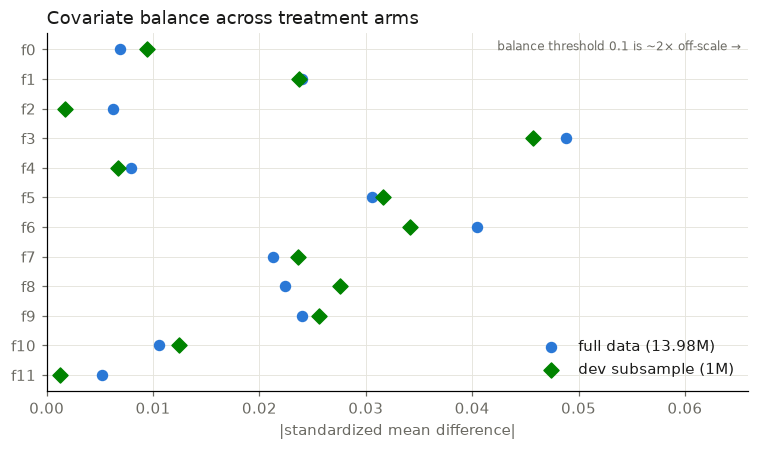

In [3]:
feats = data.CRITEO_FEATURES
ypos = np.arange(len(feats))
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(smd_full.loc[feats, "abs_smd"], ypos, color=BLUE, s=42,
           marker="o", label="full data (13.98M)", zorder=3)
ax.scatter(smd_dev.loc[feats, "abs_smd"], ypos, color=GREEN, s=48,
           marker="D", label="dev subsample (1M)", zorder=3)
ax.set_yticks(ypos, feats)
ax.invert_yaxis()
ax.set_xlabel("|standardized mean difference|")
ax.set_title("Covariate balance across treatment arms", loc="left", color=INK)
xmax = max(smd_full["abs_smd"].max(), smd_dev["abs_smd"].max())
ax.set_xlim(0, xmax * 1.35)
ax.legend(frameon=False, loc="lower right")
ax.text(0.99, 0.98, f"balance threshold 0.1 is ~{0.1/xmax:,.0f}× off-scale →",
        transform=ax.transAxes, ha="right", va="top", color=MUTED, fontsize=8)
plt.tight_layout()
plt.show()


## 2. ATE with design-based inference

Difference in means with the Neyman (unpooled) SE — the correct standard
error for a completely randomized design. `treatment` is randomized
*assignment* (ad exposure is endogenous), so these are intention-to-treat
effects. The dev-subsample estimate must land inside the full-data 95% CI —
that is the representativeness criterion for outcomes.

In [4]:
arms_full = pd.read_csv(STAGE1 / "arm_summary_full.csv", index_col=0)
display(arms_full.round(6))

rows = []
for y in ["conversion", "visit"]:
    r_dev = diff_in_means(dev[y], dev["treatment"])
    c_full, c_dev = cert["full"]["ate"][y], cert["dev"]["ate"][y]
    # cert numbers must be recomputable from the committed parquet
    assert r_dev.ate == c_dev["ate"] and r_dev.se == c_dev["se"]
    # dev point estimate inside full-data 95% CI
    assert c_full["ci_lo"] <= r_dev.ate <= c_full["ci_hi"], f"{y} not representative"
    for scope, c in [("full 13.98M", c_full), ("dev 1M", c_dev)]:
        rows.append({"outcome": y, "scope": scope, "ate": c["ate"], "se": c["se"],
                     "ci_lo": c["ci_lo"], "ci_hi": c["ci_hi"], "p": c["p_value"]})
ate_table = pd.DataFrame(rows).set_index(["outcome", "scope"])
z = cert["dev"]["cov_mean_max_abs_z"]
assert z < cert["criteria"]["cov_mean_abs_z_lt"]
print(f"covariate-moment check: max |z| vs full = {z:.2f} (criterion < 4)")
ate_table.style.format({"ate": "{:+.5%}", "se": "{:.5%}", "ci_lo": "{:+.5%}",
                        "ci_hi": "{:+.5%}", "p": "{:.2e}"})


,n,share,conversion,visit
treatment,,,,
0,2096937,0.15,0.001938,0.038201
1,11882655,0.85,0.003089,0.048543


covariate-moment check: max |z| vs full = 1.83 (criterion < 4)


## 3. Power — what can a 0.3% base rate support?

Minimal detectable absolute lift (two-proportion z-test, α=0.05, power 0.8)
at the observed ~85/15 assignment split, as a function of total sample size.
The *pooled* ATE is detectable even at 1M rows — but heterogeneity work
slices the sample (a decile at 1M has ~100k rows, where the MDE rivals the
entire effect), which is why `visit` (~25× the base rate) is the development
outcome for CATE estimation.

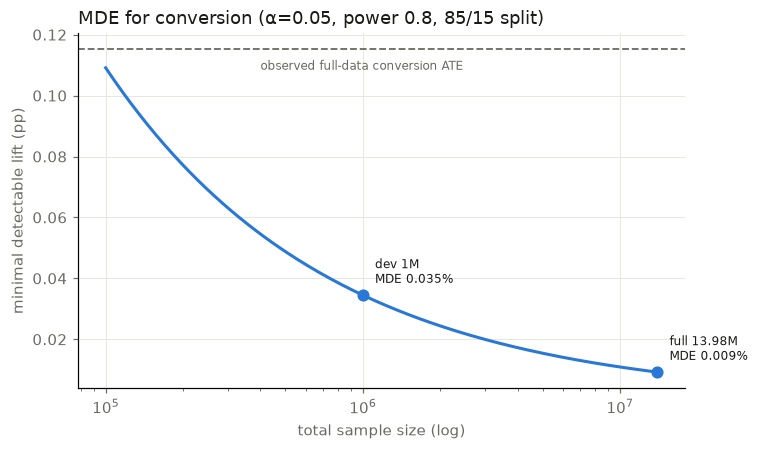

base rate p0 (control conversion): 0.1938%
MDE at 1M rows:    +0.0345% absolute (18% relative)
MDE at 13.98M rows: +0.0092% absolute (5% relative)
power to detect the observed ATE at 1M rows: 100.0%


In [5]:
m = cert["mde"]
p0, share1 = m["p0_control_conversion"], m["treated_share"]
# recompute the cert numbers in place — they must match exactly
assert mde_two_proportions(p0, int(1e6 * share1), int(1e6 * (1 - share1))) == m["mde_abs_at_1m"]
full_ate = cert["full"]["ate"]["conversion"]["ate"]

ns = np.logspace(5, np.log10(data.CRITEO_N_ROWS), 200)
mde = [mde_two_proportions(p0, int(n * share1), int(n * (1 - share1))) for n in ns]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(ns, np.array(mde) * 100, color=BLUE, lw=2)
ax.axhline(full_ate * 100, color=MUTED, lw=1.2, ls="--")
ax.text(4e5, full_ate * 100 * 0.97, "observed full-data conversion ATE",
        color=MUTED, fontsize=8, va="top")
for n, label in [(1e6, "dev 1M"), (data.CRITEO_N_ROWS, "full 13.98M")]:
    v = mde_two_proportions(p0, int(n * share1), int(n * (1 - share1)))
    ax.scatter([n], [v * 100], color=BLUE, s=48, zorder=3)
    ax.annotate(f"{label}\nMDE {v:.3%}", (n, v * 100), textcoords="offset points",
                xytext=(8, 8), fontsize=8, color=INK)
ax.set_xscale("log")
ax.set_xlabel("total sample size (log)")
ax.set_ylabel("minimal detectable lift (pp)")
ax.set_title("MDE for conversion (α=0.05, power 0.8, 85/15 split)",
             loc="left", color=INK)
plt.tight_layout()
plt.show()

print(f"base rate p0 (control conversion): {p0:.4%}")
print(f"MDE at 1M rows:    {m['mde_abs_at_1m']:+.4%} absolute "
      f"({m['mde_abs_at_1m']/p0:.0%} relative)")
print(f"MDE at 13.98M rows: {m['mde_abs_at_full']:+.4%} absolute "
      f"({m['mde_abs_at_full']/p0:.0%} relative)")
print(f"power to detect the observed ATE at 1M rows: {m['power_for_full_ate_at_1m']:.1%}")


## 4. Hillstrom (development RCT)

Three balanced arms (Mens/Womens e-mail vs none); binary `treatment` pools
the two e-mail arms. Skipped gracefully if the raw file is absent.

In [6]:
if data.HILLSTROM_PATH.exists():
    hill = data.load_hillstrom()
    display(arm_summary(hill, "segment", ["visit", "conversion", "spend"]).round(4))
    covs = ["recency", "history", "mens", "womens", "newbie",
            "history_segment", "zip_code", "channel"]
    smd_hill = smd_table(hill, "treatment", covs)
    assert smd_hill["abs_smd"].max() < 0.1, "hillstrom balance violated"
    print(f"max |SMD| (binary treatment, one-hot covariates): "
          f"{smd_hill['abs_smd'].max():.4f}")
    for y in ["visit", "conversion", "spend"]:
        r = diff_in_means(hill[y], hill["treatment"])
        unit = "" if y == "spend" else "pp"
        scale = 1 if y == "spend" else 100
        print(f"ATE {y:>10}: {r.ate*scale:+.3f}{unit} "
              f"(95% CI {r.ci_lo*scale:+.3f}..{r.ci_hi*scale:+.3f}, p={r.p_value:.1e})")
else:
    print("hillstrom.csv not present — section skipped (see REPRODUCING.md)")


,n,share,visit,conversion,spend
segment,,,,,
Mens E-Mail,21307,0.3329,0.1828,0.0125,1.4226
No E-Mail,21306,0.3329,0.1062,0.0057,0.6528
Womens E-Mail,21387,0.3342,0.1514,0.0088,1.0772


max |SMD| (binary treatment, one-hot covariates): 0.0153
ATE      visit: +6.088pp (95% CI +5.544..+6.633, p=1.6e-106)
ATE conversion: +0.495pp (95% CI +0.355..+0.636, p=5.0e-12)
ATE      spend: +0.597 (95% CI +0.376..+0.817, p=1.1e-07)


## 5. Fold discipline

Folds are a pure hash of `row_id` — independent of row order and dataset
slice — and fingerprinted. Any silent change to fold membership from here on
fails this cell and the stage gate.

In [7]:
folds = assign_folds(dev["row_id"].to_numpy())
fp = fold_fingerprint(folds)
assert fp == cert["folds"]["dev_fingerprint"], "fold assignment drifted!"
print(f"n_folds={cert['folds']['n_folds']}, seed={cert['folds']['seed']}")
print(f"fold sizes: {np.bincount(folds).tolist()}")
print(f"fingerprint: {fp[:16]}... ✓ matches cert")


n_folds=5, seed=20260717
fold sizes: [200199, 199832, 199656, 200357, 199956]
fingerprint: e1930d1b6d455404... ✓ matches cert


## Verdict

- **Balance:** randomization holds in both datasets (max |SMD| orders of
  magnitude under 0.1).
- **ATE (ITT):** positive, precisely estimated effects on both outcomes at
  full scale; dev-subsample estimates inside full-data CIs.
- **Power:** the pooled conversion ATE is detectable even at 1M rows
  (power ≈ 100%), but decile-level contrasts at 1M have MDEs rivalling the
  whole effect — `visit` is the development outcome for heterogeneity work;
  conversion finals belong to full-scale pre-registered runs (Stage 5).
- **Subsample cert:** all `subsample_cert.json` verdicts true; gate
  `uv run pytest -m gate_stage1` re-asserts everything here.

In [8]:
v = cert["verdicts"]
assert v["balance_full"] and v["cov_moments_representative"]
assert all(v["ate_representative"].values())
print("gate_stage1 preconditions: ALL GREEN")


gate_stage1 preconditions: ALL GREEN
